#### Import libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


c:\Users\supri\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Read the files

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data"/"raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data"/"raw"

calendars_df = pd.read_csv(RAW_DIR / "calendar.csv")
sell_prices_df = pd.read_csv(RAW_DIR / "sell_prices.csv")


#### Project configuration


In [3]:
RANDOM_STATE = 42

# Data sampling controls for fast notebook iteration.
N_DAYS_FOR_PIPELINE = 180
N_SAMPLE_ITEMS = 50
N_SAMPLE_STORES = 2

# Cold-start simulation controls.
N_COLD_START_ITEMS = 5
VISIBLE_DAYS = 7

# Semantic retrieval hyperparameter candidates.
TOP_K_CANDIDATES = [1, 2, 3, 5, 7, 10, 15]
TOP_K_SELECTION_METRIC = "WMAPE"

# Route A model parameters.
XGB_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE
}


##### Filtering only ~6 months of data

This is for initial validation purpose. Once the model is stabilized, will train the entire available data

In [4]:
file_path = RAW_DIR / "sales_train_validation.csv"

# Read only header
cols = pd.read_csv(file_path, nrows=0).columns.tolist()

# ID columns
id_cols = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

# Recent day columns used for the lightweight notebook pipeline.
d_cols = [c for c in cols if c.startswith("d_")]
selected_d_cols = d_cols[-N_DAYS_FOR_PIPELINE:]

use_cols = id_cols + selected_d_cols

sales_df = pd.read_csv(
    file_path,
    usecols=use_cols
)

sales_df.shape


(30490, 186)

##### Filtering 50 items & 2 stores to maintain the pipeline

There are about ~3k items & 10 stores. To reduce the complexity, filtering only 50 items & 2 stores

In [5]:
# sample items
selected_items = (
    sales_df["item_id"]
    .drop_duplicates()
    .sample(N_SAMPLE_ITEMS, random_state=RANDOM_STATE)
)

sales_small = sales_df[
    sales_df["item_id"].isin(selected_items)
].copy()

# sample stores
selected_stores = (
    sales_small["store_id"]
    .drop_duplicates()
    .sample(N_SAMPLE_STORES, random_state=RANDOM_STATE)
)

sales_small = sales_small[
    sales_small["store_id"].isin(selected_stores)
].copy()

sales_small.shape


(100, 186)

#### Melting to long format (date)

In [6]:
sales_long = sales_small.melt(
    id_vars=id_cols,
    var_name="d",
    value_name="sales"
)

sales_long.shape


(18000, 8)

#### Merge calendar dataset

In [7]:
calendar_small = calendars_df[
    calendars_df["d"].isin(selected_d_cols)
].copy()

base_df = sales_long.merge(
    calendar_small,
    on="d",
    how="left"
)

base_df.shape

(18000, 21)

#### Merge prices df

In [8]:
prices_small = sell_prices_df[
    (sell_prices_df["item_id"].isin(selected_items)) &
    (sell_prices_df["store_id"].isin(selected_stores))
].copy()

base_df = base_df.merge(
    prices_small,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

base_df.shape

(18000, 22)

#### Converting datatypes

In [9]:
base_df["date"] = pd.to_datetime(base_df["date"])

base_df.sort_values(
    ["store_id", "item_id", "date"],
    inplace=True
)

base_df.reset_index(drop=True, inplace=True)

#### EDA

##### Basic Structure

In [10]:
base_df.shape
base_df.info()
base_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            18000 non-null  str           
 1   item_id       18000 non-null  str           
 2   dept_id       18000 non-null  str           
 3   cat_id        18000 non-null  str           
 4   store_id      18000 non-null  str           
 5   state_id      18000 non-null  str           
 6   d             18000 non-null  str           
 7   sales         18000 non-null  int64         
 8   date          18000 non-null  datetime64[us]
 9   wm_yr_wk      18000 non-null  int64         
 10  weekday       18000 non-null  str           
 11  wday          18000 non-null  int64         
 12  month         18000 non-null  int64         
 13  year          18000 non-null  int64         
 14  event_name_1  1600 non-null   str           
 15  event_type_1  1600 non-null   str           
 1

,sales,date,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI,sell_price
count,18000.000000,18000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,1.365222,2016-01-25 12:00:00,11574.861111,4.005556,5.666667,2015.638889,0.333333,0.333333,0.333333,4.385092
min,0.000000,2015-10-28 00:00:00,11539.000000,1.000000,1.000000,2015.000000,0.000000,0.000000,0.000000,0.980000
25%,0.000000,2015-12-11 18:00:00,11545.750000,2.000000,2.000000,2015.000000,0.000000,0.000000,0.000000,2.480000
50%,0.000000,2016-01-25 12:00:00,11552.000000,4.000000,3.000000,2016.000000,0.000000,0.000000,0.000000,3.480000
75%,1.000000,2016-03-10 06:00:00,11606.000000,6.000000,11.000000,2016.000000,1.000000,1.000000,1.000000,4.980000
max,80.000000,2016-04-24 00:00:00,11613.000000,7.000000,12.000000,2016.000000,1.000000,1.000000,1.000000,18.870000
std,3.615661,NaN,30.635574,2.009747,4.424801,0.480336,0.471418,0.471418,0.471418,3.106413


Median sales = 0 indicates intermittent demand behavior with many zero-sale days.

<Axes: >

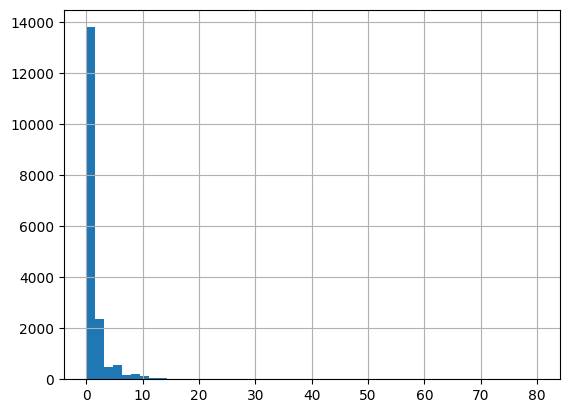

In [11]:
base_df["sales"].hist(bins=50)

Demand distribution is highly right-skewed with occasional large spikes.

##### Semantic Feasibility EDA
##### Goal:Check whether similar products/context show similar demand behavior

In [12]:
# Build item behavior summary

item_behavior = (
    base_df
    .groupby(["item_id", "cat_id", "dept_id"], as_index=False)
    .agg(
        avg_demand=("sales", "mean"),
        demand_std=("sales", "std"),
        total_sales=("sales", "sum"),
        active_days=("sales", lambda x: (x > 0).sum()),
        zero_ratio=("sales", lambda x: (x == 0).mean()),
        avg_price=("sell_price", "mean")
    )
)

In [13]:
# Add price bands

item_behavior["price_band"] = pd.qcut(
    item_behavior["avg_price"],
    q=3,
    labels=["low", "mid", "high"],
    duplicates="drop"
)

In [14]:
# Check demand behavior by category
cat_behavior = (
    item_behavior
    .groupby("cat_id")
    .agg(
        avg_demand=("avg_demand", "mean"),
        avg_zero_ratio=("zero_ratio", "mean"),
        avg_volatility=("demand_std", "mean"),
        item_count=("item_id", "count")
    )
    .reset_index()
)

cat_behavior

,cat_id,avg_demand,avg_zero_ratio,avg_volatility,item_count
0,FOODS,2.176042,0.448148,2.516760,24
1,HOBBIES,0.424206,0.717857,0.688929,7
2,HOUSEHOLD,0.687719,0.695468,1.132092,19


In [15]:
# Check demand behavior by department

dept_behavior = (
    item_behavior
    .groupby("dept_id")
    .agg(
        avg_demand=("avg_demand", "mean"),
        avg_zero_ratio=("zero_ratio", "mean"),
        avg_volatility=("demand_std", "mean"),
        item_count=("item_id", "count")
    )
    .reset_index()
    .sort_values("avg_demand", ascending=False)
)

dept_behavior

,dept_id,avg_demand,avg_zero_ratio,avg_volatility,item_count
1,FOODS_2,4.456944,0.331019,5.262412,6
2,FOODS_3,1.449074,0.482037,1.549539,15
0,FOODS_1,1.249074,0.512963,1.861559,3
5,HOUSEHOLD_1,1.020062,0.606481,1.515913,9
3,HOBBIES_1,0.579167,0.629167,0.815413,4
6,HOUSEHOLD_2,0.388611,0.775556,0.786653,10
4,HOBBIES_2,0.217593,0.836111,0.520282,3


In [16]:
# Check demand behavior by price band
price_behavior = (
    item_behavior
    .groupby("price_band")
    .agg(
        avg_demand=("avg_demand", "mean"),
        avg_zero_ratio=("zero_ratio", "mean"),
        avg_volatility=("demand_std", "mean"),
        item_count=("item_id", "count")
    )
    .reset_index()
)

price_behavior

,price_band,avg_demand,avg_zero_ratio,avg_volatility,item_count
0,low,2.804248,0.387255,3.178046,17
1,mid,0.643750,0.676562,0.928428,16
2,high,0.605229,0.681536,1.050169,17


In [17]:
# Strongest validation: matched vs random similarity

# Attribute group = dept + price band + cat_id
# Item-level semantic feasibility check


item_behavior["attribute_group"] = (
    item_behavior["dept_id"].astype(str)
    + "_" + item_behavior["price_band"].astype(str)
    + "_" + item_behavior["cat_id"].astype(str)
)

In [18]:
comparison_results = []

for idx, row in item_behavior.iterrows():
    
    same_group = item_behavior[
        (item_behavior["attribute_group"] == row["attribute_group"]) &
        ~(
            (item_behavior["item_id"] == row["item_id"]) 
        )
    ]
    
    random_group = item_behavior[
        ~(
            (item_behavior["item_id"] == row["item_id"]) 
        )
    ]
    
    if len(same_group) == 0:
        continue
    
    same_sample = same_group.sample(
        n=min(5, len(same_group)),
        random_state=42
    )
    
    random_sample = random_group.sample(
        n=min(5, len(random_group)),
        random_state=42
    )
    
    same_avg_demand_diff = np.abs(
        same_sample["avg_demand"] - row["avg_demand"]
    ).mean()
    
    random_avg_demand_diff = np.abs(
        random_sample["avg_demand"] - row["avg_demand"]
    ).mean()
    
    same_zero_ratio_diff = np.abs(
        same_sample["zero_ratio"] - row["zero_ratio"]
    ).mean()
    
    random_zero_ratio_diff = np.abs(
        random_sample["zero_ratio"] - row["zero_ratio"]
    ).mean()
    
    same_volatility_diff = np.abs(
        same_sample["demand_std"] - row["demand_std"]
    ).mean()
    
    random_volatility_diff = np.abs(
        random_sample["demand_std"] - row["demand_std"]
    ).mean()
    
    comparison_results.append({
        "item_id": row["item_id"],
        "attribute_group": row["attribute_group"],
        "same_avg_demand_diff": same_avg_demand_diff,
        "random_avg_demand_diff": random_avg_demand_diff,
        "same_zero_ratio_diff": same_zero_ratio_diff,
        "random_zero_ratio_diff": random_zero_ratio_diff,
        "same_volatility_diff": same_volatility_diff,
        "random_volatility_diff": random_volatility_diff
    })

semantic_feasibility_df = pd.DataFrame(comparison_results)

In [19]:
semantic_summary = pd.DataFrame({
    "metric": [
        "avg_demand_diff",
        "zero_ratio_diff",
        "volatility_diff"
    ],
    "same_attribute_group": [
        semantic_feasibility_df["same_avg_demand_diff"].mean(),
        semantic_feasibility_df["same_zero_ratio_diff"].mean(),
        semantic_feasibility_df["same_volatility_diff"].mean()
    ],
    "random_products": [
        semantic_feasibility_df["random_avg_demand_diff"].mean(),
        semantic_feasibility_df["random_zero_ratio_diff"].mean(),
        semantic_feasibility_df["random_volatility_diff"].mean()
    ]
})

semantic_summary["improvement_vs_random"] = (
    semantic_summary["random_products"]
    - semantic_summary["same_attribute_group"]
)

semantic_summary

,metric,same_attribute_group,random_products,improvement_vs_random
0,avg_demand_diff,1.290261,1.343333,0.053072
1,zero_ratio_diff,0.151061,0.243952,0.092891
2,volatility_diff,1.300780,1.277064,-0.023716


#### Choosing cold start skus

In [20]:
def create_simulated_cold_start_split(
    base_df,
    n_cold_start_items=N_COLD_START_ITEMS,
    visible_days=VISIBLE_DAYS,
    random_state=RANDOM_STATE
):
    df = base_df.copy()

    cold_start_items = (
        df["item_id"]
        .drop_duplicates()
        .sample(n_cold_start_items, random_state=random_state)
        .tolist()
    )

    # Preserve the real target before masking cold-start history.
    df["actual_sales"] = df["sales"]

    df = df.sort_values(["store_id", "item_id", "date"]).copy()

    df["day_number_for_item_store"] = (
        df
        .groupby(["store_id", "item_id"])
        .cumcount() + 1
    )

    # Route B simulates products with only the first few observed days available.
    df.loc[
        (df["item_id"].isin(cold_start_items))
        & (df["day_number_for_item_store"] > visible_days),
        "sales"
    ] = np.nan

    route_a_df = df[
        ~df["item_id"].isin(cold_start_items)
    ].copy()

    route_b_df = df[
        df["item_id"].isin(cold_start_items)
    ].copy()

    print("cold_start_items", cold_start_items)
    print("Route A shape", route_a_df.shape)
    print("Route B shape", route_b_df.shape)
    print(route_b_df.groupby(["store_id", "item_id"])["sales"].count())

    return df, route_a_df, route_b_df, cold_start_items


#### Creating Route A and Route B 

In [21]:
df, route_a_df, route_b_df, cold_start_items = create_simulated_cold_start_split(
    base_df=base_df,
    n_cold_start_items=N_COLD_START_ITEMS,
    visible_days=VISIBLE_DAYS,
    random_state=RANDOM_STATE
)


cold_start_items ['FOODS_3_189', 'HOUSEHOLD_1_486', 'HOBBIES_2_139', 'HOUSEHOLD_2_364', 'FOODS_3_439']
Route A shape (16200, 24)
Route B shape (1800, 24)
store_id  item_id        
CA_2      FOODS_3_189        7
          FOODS_3_439        7
          HOBBIES_2_139      7
          HOUSEHOLD_1_486    7
          HOUSEHOLD_2_364    7
WI_2      FOODS_3_189        7
          FOODS_3_439        7
          HOBBIES_2_139      7
          HOUSEHOLD_1_486    7
          HOUSEHOLD_2_364    7
Name: sales, dtype: int64


#### Route A → classical forecasting pipeline

##### EDA

<Axes: xlabel='date'>

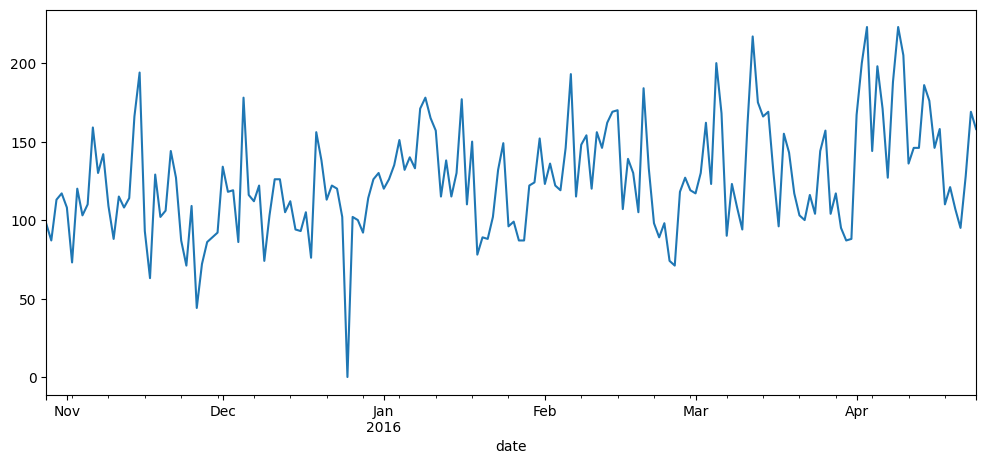

In [22]:
daily_sales = (
    route_a_df
    .groupby("date")["sales"]
    .sum()
)

daily_sales.plot(figsize=(12,5))

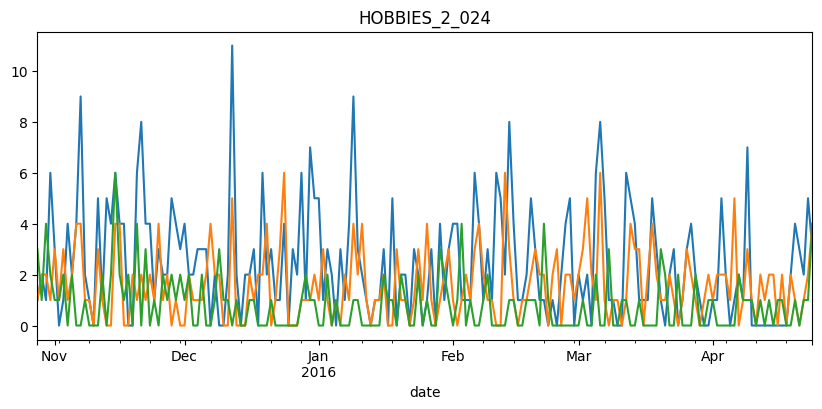

In [23]:
sample_items = (
    route_a_df["item_id"]
    .drop_duplicates()
    .sample(3, random_state=42)
)

for item in sample_items:
    (
        route_a_df[
            route_a_df["item_id"] == item
        ]
        .groupby("date")["sales"]
        .sum()
        .plot(figsize=(10,4), title=item)
    )

SKU-level analysis shows bursty and intermittent demand patterns with frequent zero-demand periods.

In [24]:
route_a_df.groupby("cat_id")["sales"].sum()

cat_id
FOODS        17303.0
HOBBIES       1013.0
HOUSEHOLD     4372.0
Name: sales, dtype: float64

FOODS category dominates total demand volume within the selected subset.

In [25]:
route_a_df["sell_price"].describe()

count    16200.000000
mean         4.102993
std          2.440481
min          0.980000
25%          2.460000
50%          3.480000
75%          4.980000
max         12.680000
Name: sell_price, dtype: float64

In [26]:
route_a_df.groupby("item_id")["sell_price"].nunique().describe()

count    45.000000
mean      1.311111
std       0.701370
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       5.000000
Name: sell_price, dtype: float64

Most products exhibit limited price variation, suggesting weak price signal contribution in this subset.

In [27]:
route_a_df.isnull().sum()

id                               0
item_id                          0
dept_id                          0
cat_id                           0
store_id                         0
state_id                         0
d                                0
sales                            0
date                             0
wm_yr_wk                         0
weekday                          0
wday                             0
month                            0
year                             0
event_name_1                 14760
event_type_1                 14760
event_name_2                 16200
event_type_2                 16200
snap_CA                          0
snap_TX                          0
snap_WI                          0
sell_price                       0
actual_sales                     0
day_number_for_item_store        0
dtype: int64

In [28]:
route_a_df.groupby("weekday")["sales"].mean()

weekday
Friday       1.370513
Monday       1.316000
Saturday     1.732479
Sunday       1.573504
Thursday     1.223932
Tuesday      1.292000
Wednesday    1.287607
Name: sales, dtype: float64

Weekend sales are comparatively higher, indicating weekly seasonality patterns.

##### Feature Engineering

In [29]:
route_a_df = route_a_df.sort_values(
    ["store_id", "item_id", "date"]
)

In [30]:
# Create lag features
lags = [1, 7, 14, 28]

for lag in lags:
    route_a_df[f"lag_{lag}"] = (
        route_a_df
        .groupby(["store_id", "item_id"])["sales"]
        .shift(lag)
    )

In [31]:
# Create rolling features
route_a_df["rolling_mean_7"] = (
    route_a_df
    .groupby(["store_id", "item_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

route_a_df["rolling_std_7"] = (
    route_a_df
    .groupby(["store_id", "item_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

route_a_df["rolling_mean_14"] = (
    route_a_df
    .groupby(["store_id", "item_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

##### Handling Null Values

In [32]:
route_a_df.info()

<class 'pandas.DataFrame'>
Index: 16200 entries, 0 to 17999
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         16200 non-null  str           
 1   item_id                    16200 non-null  str           
 2   dept_id                    16200 non-null  str           
 3   cat_id                     16200 non-null  str           
 4   store_id                   16200 non-null  str           
 5   state_id                   16200 non-null  str           
 6   d                          16200 non-null  str           
 7   sales                      16200 non-null  float64       
 8   date                       16200 non-null  datetime64[us]
 9   wm_yr_wk                   16200 non-null  int64         
 10  weekday                    16200 non-null  str           
 11  wday                       16200 non-null  int64         
 12  month               

In [33]:
event_cols = [
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

for col in event_cols:
    route_a_df[col] = route_a_df[col].fillna("No_Event")

lag_roll_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14"
]

route_a_df = route_a_df.dropna(
    subset=lag_roll_cols
).copy()

In [34]:
# Create simple event flags
route_a_df["is_event"] = (route_a_df["event_name_1"] != "No_Event").astype(int)

In [35]:
# Price change
route_a_df["price_change"] = (
    route_a_df
    .groupby(["store_id", "item_id"])["sell_price"]
    .pct_change()
)

route_a_df["price_change"] = route_a_df["price_change"].fillna(0)

##### Feature list

In [36]:
feature_cols = [
    # historical demand
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_14",

    # calendar
    "wday", "month", "year", "snap_CA", "snap_TX", "snap_WI", "is_event",

    # product/store
    "item_id_enc", "dept_id_enc", "cat_id_enc", "store_id_enc", "state_id_enc",
    # price
    "sell_price", "price_change"
]

##### Label encoding the categorical features

In [37]:
cat_cols = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    route_a_df[col+'_enc'] = le.fit_transform(route_a_df[col].astype(str))
    encoders[col+'_enc'] = le

##### Train - Test Split

In [38]:
split_date = route_a_df["date"].quantile(0.8)

train_df = route_a_df[route_a_df["date"] <= split_date]
test_df = route_a_df[route_a_df["date"] > split_date]

X_train = train_df[feature_cols]
y_train = train_df["sales"]

X_test = test_df[feature_cols]
y_test = test_df["sales"]

##### Model fit

In [39]:
model = XGBRegressor(**XGB_PARAMS)

model.fit(X_train, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

##### Predict the sales

In [40]:
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)


In [41]:
pred_df = test_df.copy()
pred_df["prediction"] = y_pred

# Create model forecasts for all Route A rows. Route B uses these forecasts as
# peer demand signals, avoiding same-date actual-sales leakage from analog SKUs.
route_a_model_pred_df = route_a_df.copy()
route_a_model_pred_df["model_prediction"] = model.predict(
    route_a_model_pred_df[feature_cols]
)
route_a_model_pred_df["model_prediction"] = route_a_model_pred_df[
    "model_prediction"
].clip(lower=0)


##### Evaluation Metrics

In [42]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

wmape = (
    np.abs(y_test - y_pred).sum()
    / y_test.sum()
)

print("MAE:", mae)
print("RMSE:", rmse)
print("WMAPE:", wmape)

route_a_metrics_df = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "WMAPE": [wmape]
})

MAE: 1.1198793267513867
RMSE: 2.069357524580654
WMAPE: 0.6755304249840804


##### Actual vs Predicted

<Axes: xlabel='date'>

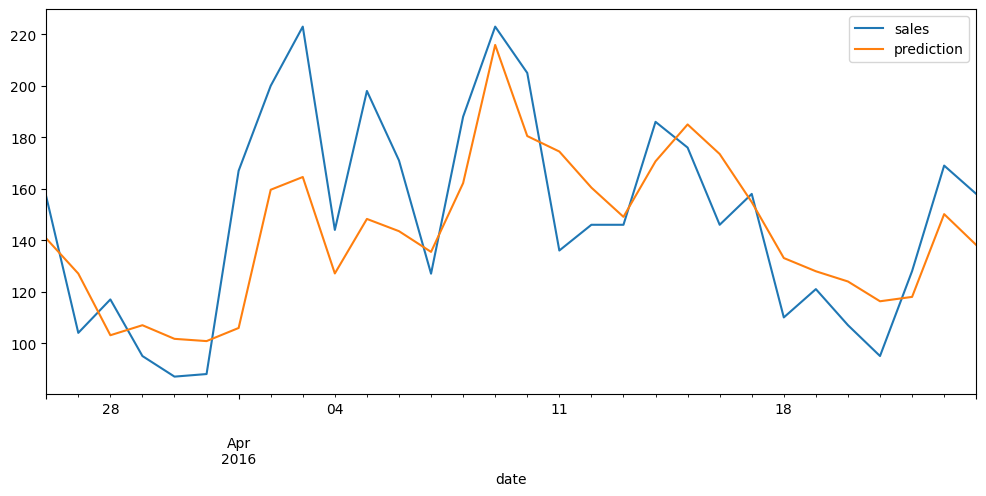

In [43]:
daily_compare = (
    pred_df
    .groupby("date")[["sales", "prediction"]]
    .sum()
)

daily_compare.plot(figsize=(12,5))

<Axes: xlabel='date'>

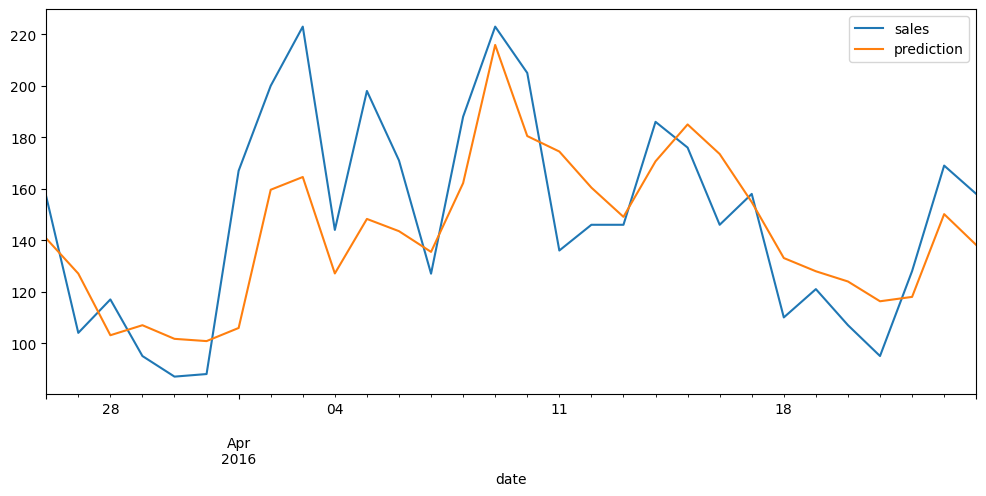

In [44]:
daily_compare = (
    pred_df
    .groupby("date")[["sales", "prediction"]]
    .sum()
)

daily_compare.plot(figsize=(12,5))

##### Feature Importance

In [45]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

#### Route B → Low-history / cold-start forecasting

##### Forecasting products with insufficient historical signal

Product Attributes
        
        ↓
Semantic Representation
        
        ↓
Embedding Vector
       
        ↓
Similarity Retrieval
        
        ↓
Top-K Similar Products
        
        ↓
Transfer Demand Prior
        
        ↓
Forecast Estimate

In [46]:
route_b_df.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'actual_sales',
       'day_number_for_item_store'],
      dtype='str')

##### Build item level product master

In [47]:
# Item-level product master
product_master = (
    df[["item_id", "dept_id", "cat_id"]]
    .drop_duplicates()
    .copy()
)

# Average price per item
avg_price = (
    df.groupby("item_id")["sell_price"]
    .mean()
    .reset_index(name="avg_sell_price")
)

product_master = product_master.merge(
    avg_price,
    on="item_id",
    how="left"
)

product_master["price_band"] = pd.qcut(
    product_master["avg_sell_price"],
    q=3,
    labels=["low", "mid", "high"],
    duplicates="drop"
)

##### Enriching features - Available route a df

In [48]:
# Use all available Route A rows for similarity priors, not only rows kept after
# lag-feature filtering in the forecasting model.
route_a_similarity_base = df[
    ~df["item_id"].isin(cold_start_items)
].copy()

route_a_stats = (
    route_a_similarity_base
    .groupby("item_id")["actual_sales"]
    .agg(avg_demand="mean", demand_std="std")
    .reset_index()
)

route_a_zero = (
    route_a_similarity_base
    .groupby("item_id")["actual_sales"]
    .apply(lambda x: (x == 0).mean())
    .reset_index(name="zero_ratio")
)

route_a_stats = route_a_stats.merge(route_a_zero, on="item_id", how="left")


##### Enriching features - Route b df

In [49]:
route_b_visible = route_b_df[route_b_df["sales"].notna()].copy()

route_b_stats = (
    route_b_visible
    .groupby("item_id")["sales"]
    .agg(avg_demand="mean", demand_std="std")
    .reset_index()
)

route_b_zero = (
    route_b_visible
    .groupby("item_id")["sales"]
    .apply(lambda x: (x == 0).mean())
    .reset_index(name="zero_ratio")
)

route_b_stats = route_b_stats.merge(route_b_zero, on="item_id", how="left")

In [50]:
behavior_stats = pd.concat(
    [route_a_stats, route_b_stats],
    ignore_index=True
)

product_master = product_master.merge(
    behavior_stats,
    on="item_id",
    how="left"
)

In [51]:
product_master["demand_band"] = pd.qcut(
    product_master["avg_demand"],
    q=3,
    labels=["low", "medium", "high"],
    duplicates="drop"
)

product_master["volatility_band"] = pd.qcut(
    product_master["demand_std"].fillna(0),
    q=3,
    labels=["low", "medium", "high"],
    duplicates="drop"
)

product_master["intermittent_flag"] = np.where(
    product_master["zero_ratio"] > 0.5,
    "intermittent",
    "dense"
)

##### Create semantic text

In [52]:
product_master["semantic_text"] = (
    "category " + product_master["cat_id"].astype(str)
    + " department " + product_master["dept_id"].astype(str)
    + " price " + product_master["price_band"].astype(str)
    + " demand " + product_master["demand_band"].astype(str)
    + " volatility " + product_master["volatility_band"].astype(str)
    + " pattern " + product_master["intermittent_flag"].astype(str)
)

In [53]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3434.40it/s]


In [54]:
embeddings = embedding_model.encode(
    product_master["semantic_text"].tolist(),
    show_progress_bar=True
)
product_master["embedding"] = list(embeddings)

Batches: 100%|██████████| 2/2 [00:00<00:00,  8.11it/s]


##### Build similarity matrix

In [55]:
# Route A and Route B item lists
route_a_items = route_a_df["item_id"].unique()
route_b_items = route_b_df["item_id"].unique()

# Product master split
pm_a = product_master[product_master["item_id"].isin(route_a_items)].copy()
pm_b = product_master[product_master["item_id"].isin(route_b_items)].copy()

# Convert embeddings to matrix
emb_a = np.vstack(pm_a["embedding"].values)
emb_b = np.vstack(pm_b["embedding"].values)

# Similarity matrix: Route B items vs Route A items
sim_matrix = cosine_similarity(emb_b, emb_a)

sim_matrix.shape

(5, 45)

##### Tune Top-K similarity retrieval


In [56]:
# Build a full similarity table once. Different Top-K values can then be tested
# without recomputing embeddings or cosine similarities.
similarity_results = []

for i, b_item in enumerate(pm_b["item_id"].values):
    ranked_idx = np.argsort(sim_matrix[i])[::-1]

    for rank, idx in enumerate(ranked_idx, start=1):
        similarity_results.append({
            "route_b_item": b_item,
            "similar_item": pm_a.iloc[idx]["item_id"],
            "similarity_rank": rank,
            "similarity_score": sim_matrix[i][idx],
            "similar_cat": pm_a.iloc[idx]["cat_id"],
            "similar_dept": pm_a.iloc[idx]["dept_id"],
            "similar_price_band": pm_a.iloc[idx]["price_band"]
        })

similarity_df = pd.DataFrame(similarity_results)


##### Select best Top-K match table


In [57]:
def get_topk_similarity(similarity_df, top_k):
    return (
        similarity_df
        .sort_values(
            ["route_b_item", "similarity_score"],
            ascending=[True, False]
        )
        .groupby("route_b_item")
        .head(top_k)
        .copy()
    )


def compute_forecast_metrics(df, actual_col, pred_col):
    temp = df[[actual_col, pred_col]].dropna().copy()

    if temp.empty:
        return np.nan, np.nan, np.nan, np.nan, 0

    error = temp[actual_col] - temp[pred_col]
    abs_error = np.abs(error)
    actual_sum = temp[actual_col].sum()

    mae = mean_absolute_error(temp[actual_col], temp[pred_col])
    rmse = np.sqrt(mean_squared_error(temp[actual_col], temp[pred_col]))
    wmape = abs_error.sum() / actual_sum if actual_sum != 0 else np.nan
    bias = error.sum() / actual_sum if actual_sum != 0 else np.nan

    return mae, rmse, wmape, bias, len(temp)


def build_candidate_topk_forecast(candidate_topk_similarity):
    route_b_hidden = route_b_df[
        route_b_df["sales"].isna()
    ].copy()

    visible_launch_fallback = (
        route_b_df[route_b_df["sales"].notna()]
        .groupby(["item_id", "store_id"])["sales"]
        .mean()
        .to_dict()
    )
    semantic_global_fallback = route_a_model_pred_df["model_prediction"].mean()
    forecast_results = []

    for _, row in route_b_hidden.iterrows():
        b_item = row["item_id"]
        store = row["store_id"]
        date = row["date"]

        similar_items_df = candidate_topk_similarity[
            candidate_topk_similarity["route_b_item"] == b_item
        ].copy()

        weighted_sales = []
        weights = []

        for _, sim_row in similar_items_df.iterrows():
            similar_item = sim_row["similar_item"]
            similarity_score = sim_row["similarity_score"]

            matched_rows = route_a_model_pred_df[
                (route_a_model_pred_df["item_id"] == similar_item)
                & (route_a_model_pred_df["date"] == date)
            ]

            if len(matched_rows) > 0:
                similar_forecast = matched_rows["model_prediction"].mean()
                weighted_sales.append(similar_forecast * similarity_score)
                weights.append(similarity_score)

        if len(weights) > 0:
            predicted_sales = sum(weighted_sales) / sum(weights)
            forecast_source = "semantic_topk_model_transfer"
        else:
            predicted_sales = visible_launch_fallback.get(
                (b_item, store),
                semantic_global_fallback
            )
            forecast_source = "visible_launch_fallback"

        forecast_results.append({
            "route_b_item": b_item,
            "store_id": store,
            "date": date,
            "predicted_sales": predicted_sales,
            "forecast_source": forecast_source,
            "actual_sales": row["actual_sales"]
        })

    return pd.DataFrame(forecast_results)


topk_experiment_results = []

for candidate_top_k in TOP_K_CANDIDATES:
    candidate_topk_similarity = get_topk_similarity(
        similarity_df,
        top_k=candidate_top_k
    )
    candidate_forecast_df = build_candidate_topk_forecast(
        candidate_topk_similarity
    )
    mae, rmse, wmape, bias, n_rows = compute_forecast_metrics(
        candidate_forecast_df,
        actual_col="actual_sales",
        pred_col="predicted_sales"
    )

    topk_experiment_results.append({
        "top_k": candidate_top_k,
        "MAE": mae,
        "RMSE": rmse,
        "WMAPE": wmape,
        "Bias": bias,
        "Rows Evaluated": n_rows
    })

topk_experiment_results_df = pd.DataFrame(topk_experiment_results)

topk_experiment_results_df.sort_values(TOP_K_SELECTION_METRIC)


,top_k,MAE,RMSE,WMAPE,Bias,Rows Evaluated
3,5,0.992071,1.554955,0.954551,-0.123592,1730
2,3,1.020172,1.571629,0.981590,-0.263457,1730
4,7,1.072343,1.614396,1.031787,-0.255855,1730
5,10,1.101363,1.653265,1.059709,-0.412794,1730
1,2,1.109578,1.696333,1.067614,-0.430303,1730
6,15,1.225221,1.800917,1.178883,-0.466047,1730
0,1,1.280955,2.072735,1.232509,-0.334229,1730


##### Create Mapping Dictionary

- Top-K is selected using the simulated cold-start holdout set. 
- In a real deployment, this value would be tuned using historical launch backtests, not future unknown sales.

In [58]:
# Select best K from simulated holdout evaluation

best_top_k = int(
    topk_experiment_results_df
    .sort_values(TOP_K_SELECTION_METRIC)
    .iloc[0]["top_k"]
)

print("Best top_k:", best_top_k)

topk_similarity = get_topk_similarity(
    similarity_df,
    top_k=best_top_k
)

# Build mapping: each Route B item -> list of selected Route A items with scores.
topk_mapping = (
    topk_similarity
    .groupby("route_b_item")
    .apply(
        lambda x: list(
            zip(x["similar_item"], x["similarity_score"])
        )
    )
    .to_dict()
)

topk_similarity


Best top_k: 5


,route_b_item,similar_item,similarity_rank,similarity_score,similar_cat,similar_dept,similar_price_band
0,FOODS_3_189,FOODS_3_062,1,1.000000,FOODS,FOODS_3,low
1,FOODS_3_189,FOODS_3_395,2,0.972235,FOODS,FOODS_3,mid
2,FOODS_3_189,FOODS_2_186,3,0.952335,FOODS,FOODS_2,high
3,FOODS_3_189,FOODS_3_583,4,0.940440,FOODS,FOODS_3,low
4,FOODS_3_189,FOODS_3_118,5,0.940440,FOODS,FOODS_3,low
45,FOODS_3_439,FOODS_3_583,1,0.985425,FOODS,FOODS_3,low
46,FOODS_3_439,FOODS_3_744,2,0.985425,FOODS,FOODS_3,low
47,FOODS_3_439,FOODS_3_118,3,0.985425,FOODS,FOODS_3,low
48,FOODS_3_439,FOODS_3_395,4,0.981137,FOODS,FOODS_3,mid
49,FOODS_3_439,FOODS_1_101,5,0.954251,FOODS,FOODS_1,low


##### Build route b forecast rows

In [59]:
# 2. Build forecast rows: only hidden Route B rows need prediction

route_b_hidden = route_b_df[
    route_b_df["sales"].isna()
].copy()

forecast_rows = []

for _, row in route_b_hidden.iterrows():

    b_item = row["item_id"]
    store = row["store_id"]
    date = row["date"]

    similar_items = topk_mapping.get(b_item, [])

    forecast_rows.append({
        "route_b_item": b_item,
        "store_id": store,
        "date": date,
        "actual_sales": row["actual_sales"],
        "similar_items": similar_items
    })

forecast_base_df = pd.DataFrame(forecast_rows)

##### Transfer demand from matched Route A item

In [60]:
route_b_hidden = route_b_df[
    route_b_df["sales"].isna()
].copy()

visible_launch_fallback = (
    route_b_df[route_b_df["sales"].notna()]
    .groupby(["item_id", "store_id"])["sales"]
    .mean()
    .to_dict()
)

semantic_global_fallback = route_a_model_pred_df["model_prediction"].mean()

forecast_results = []

for _, row in route_b_hidden.iterrows():

    b_item = row["item_id"]
    store = row["store_id"]
    date = row["date"]

    similar_items_df = topk_similarity[
        topk_similarity["route_b_item"] == b_item
    ].copy()

    weighted_sales = []
    weights = []

    for _, sim_row in similar_items_df.iterrows():

        similar_item = sim_row["similar_item"]
        similarity_score = sim_row["similarity_score"]

        matched_rows = route_a_model_pred_df[
            (route_a_model_pred_df["item_id"] == similar_item)
            & (route_a_model_pred_df["date"] == date)
        ]

        if len(matched_rows) > 0:
            similar_forecast = matched_rows["model_prediction"].mean()

            weighted_sales.append(similar_forecast * similarity_score)
            weights.append(similarity_score)

    if len(weights) > 0:
        predicted_sales = sum(weighted_sales) / sum(weights)
        forecast_source = "semantic_topk_model_transfer"
    else:
        predicted_sales = visible_launch_fallback.get(
            (b_item, store),
            semantic_global_fallback
        )
        forecast_source = "visible_launch_fallback"

    forecast_results.append({
        "route_b_item": b_item,
        "store_id": store,
        "date": date,
        "predicted_sales": predicted_sales,
        "forecast_source": forecast_source,
        "actual_sales": row["actual_sales"]
    })

forecast_df_topk = pd.DataFrame(forecast_results)

In [61]:
forecast_df_topk = forecast_df_topk.dropna().copy()

mae = mean_absolute_error(
    forecast_df_topk["actual_sales"],
    forecast_df_topk["predicted_sales"]
)

rmse = np.sqrt(
    mean_squared_error(
        forecast_df_topk["actual_sales"],
        forecast_df_topk["predicted_sales"]
    )
)

wmape = (
    np.abs(
        forecast_df_topk["actual_sales"]
        - forecast_df_topk["predicted_sales"]
    ).sum()
    / forecast_df_topk["actual_sales"].sum()
)

print("Leakage-safe Top-K Weighted MAE:", mae)
print("Leakage-safe Top-K Weighted RMSE:", rmse)
print("Leakage-safe Top-K Weighted WMAPE:", wmape)
print(forecast_df_topk["forecast_source"].value_counts())


Leakage-safe Top-K Weighted MAE: 0.9920709872816733
Leakage-safe Top-K Weighted RMSE: 1.5549554032628388
Leakage-safe Top-K Weighted WMAPE: 0.9545510611775834
forecast_source
semantic_topk_model_transfer    1520
visible_launch_fallback          210
Name: count, dtype: int64


##### Create hidden Route B rows

In [62]:
# Hidden Route B rows are the rows we are forecasting
route_b_hidden = route_b_df[
    route_b_df["sales"].isna()
].copy()

route_b_hidden = route_b_hidden[
    [
        "item_id",
        "store_id",
        "date",
        "cat_id",
        "dept_id",
        "actual_sales"
    ]
].copy()

##### Build baselines only from Route A

In [63]:
# Build baselines from Route A and from only the visible launch history of Route B.
route_a_baseline_base = df[
    ~df["item_id"].isin(cold_start_items)
].copy()

cat_avg = (
    route_a_baseline_base
    .groupby("cat_id")["actual_sales"]
    .mean()
    .reset_index(name="cat_avg_forecast")
)

dept_avg = (
    route_a_baseline_base
    .groupby("dept_id")["actual_sales"]
    .mean()
    .reset_index(name="dept_avg_forecast")
)

store_cat_avg = (
    route_a_baseline_base
    .groupby(["store_id", "cat_id"])["actual_sales"]
    .mean()
    .reset_index(name="store_cat_avg_forecast")
)

visible_launch_avg = (
    route_b_df[route_b_df["sales"].notna()]
    .groupby(["item_id", "store_id"])["sales"]
    .mean()
    .reset_index(name="visible_launch_avg_forecast")
)

global_avg = route_a_baseline_base["actual_sales"].mean()


##### Merge baseline forecasts to hidden Route B rows

In [64]:
baseline_df = route_b_hidden.merge(
    cat_avg,
    on="cat_id",
    how="left"
)

baseline_df = baseline_df.merge(
    dept_avg,
    on="dept_id",
    how="left"
)

baseline_df = baseline_df.merge(
    store_cat_avg,
    on=["store_id", "cat_id"],
    how="left"
)

baseline_df = baseline_df.merge(
    visible_launch_avg,
    on=["item_id", "store_id"],
    how="left"
)

baseline_cols = [
    "cat_avg_forecast",
    "dept_avg_forecast",
    "store_cat_avg_forecast",
    "visible_launch_avg_forecast"
]

for col in baseline_cols:
    baseline_df[col] = baseline_df[col].fillna(global_avg)


##### Bring semantic forecast into same table

In [65]:
semantic_eval_df = forecast_df_topk.rename(
    columns={
        "route_b_item": "item_id",
        "predicted_sales": "semantic_topk_forecast"
    }
)

semantic_eval_df = semantic_eval_df[
    [
        "item_id",
        "store_id",
        "date",
        "semantic_topk_forecast"
    ]
]

comparison_df = baseline_df.merge(
    semantic_eval_df,
    on=["item_id", "store_id", "date"],
    how="left"
)

##### Metric function

In [66]:
def evaluate_forecast(df, actual_col, pred_col):
    temp = df[[actual_col, pred_col]].dropna().copy()

    if temp.empty:
        return np.nan, np.nan, np.nan, np.nan, 0

    error = temp[actual_col] - temp[pred_col]
    abs_error = np.abs(error)

    mae = mean_absolute_error(
        temp[actual_col],
        temp[pred_col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            temp[actual_col],
            temp[pred_col]
        )
    )

    actual_sum = temp[actual_col].sum()
    wmape = abs_error.sum() / actual_sum if actual_sum != 0 else np.nan

    bias = error.sum() / actual_sum if actual_sum != 0 else np.nan

    return mae, rmse, wmape, bias, len(temp)


##### Compare all methods

In [67]:
results = []

forecast_cols = {
    "Category Average": "cat_avg_forecast",
    "Department Average": "dept_avg_forecast",
    "Store-Category Average": "store_cat_avg_forecast",
    "Visible Launch Average": "visible_launch_avg_forecast",
    "Semantic Top-K Model Transfer": "semantic_topk_forecast"
}

for method, pred_col in forecast_cols.items():
    mae, rmse, wmape, bias, n_rows = evaluate_forecast(
        comparison_df,
        actual_col="actual_sales",
        pred_col=pred_col
    )

    results.append({
        "method": method,
        "MAE": mae,
        "RMSE": rmse,
        "WMAPE": wmape,
        "Bias": bias,
        "Rows Evaluated": n_rows
    })

baseline_comparison_results = pd.DataFrame(results)

baseline_comparison_results.sort_values("WMAPE")





,method,MAE,RMSE,WMAPE,Bias,Rows Evaluated
3,Visible Launch Average,0.858629,1.348910,0.826156,-0.209598,1730
4,Semantic Top-K Model Transfer,0.992071,1.554955,0.954551,-0.123592,1730
1,Department Average,1.055131,1.793625,1.015226,0.149386,1730
0,Category Average,1.174568,1.743377,1.130146,-0.206032,1730
2,Store-Category Average,1.302192,1.976649,1.252944,-0.206032,1730


In [68]:


(
    similarity_df.groupby("route_b_item")["similar_dept"]
    .nunique()
    .describe()
)

count    5.0
mean     7.0
std      0.0
min      7.0
25%      7.0
50%      7.0
75%      7.0
max      7.0
Name: similar_dept, dtype: float64

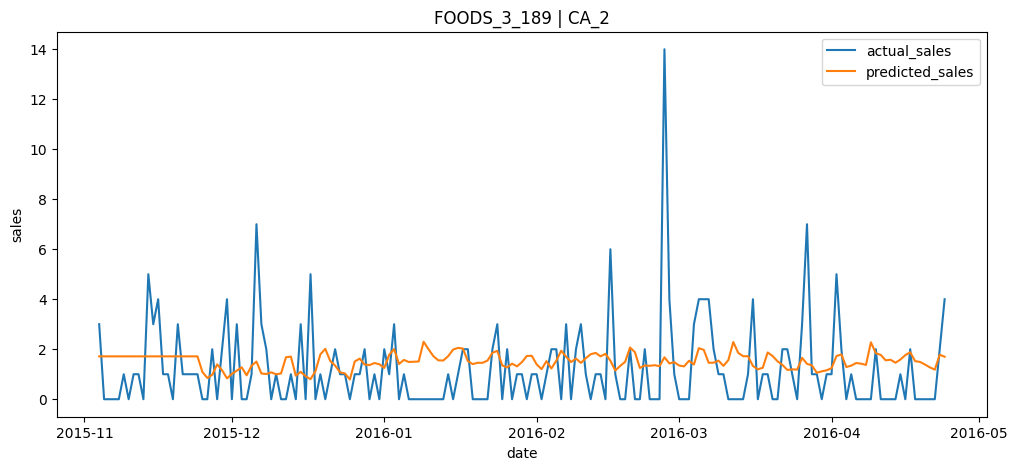

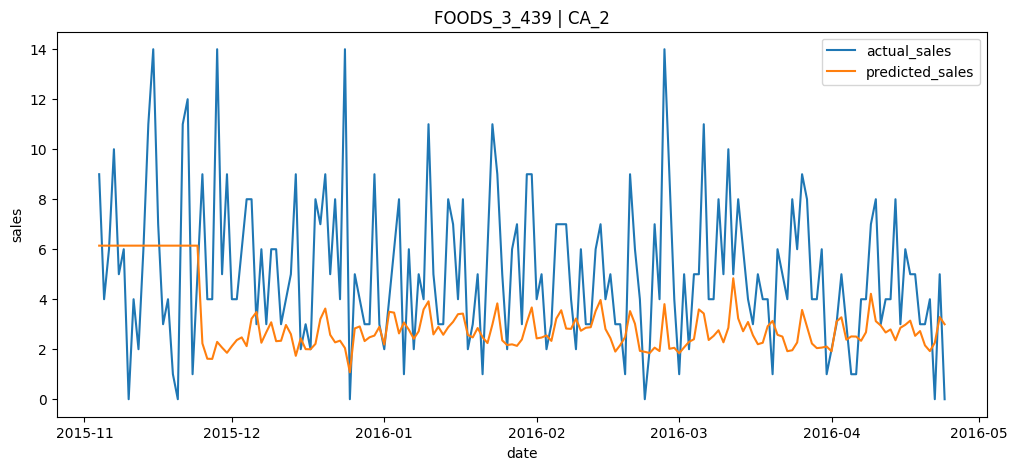

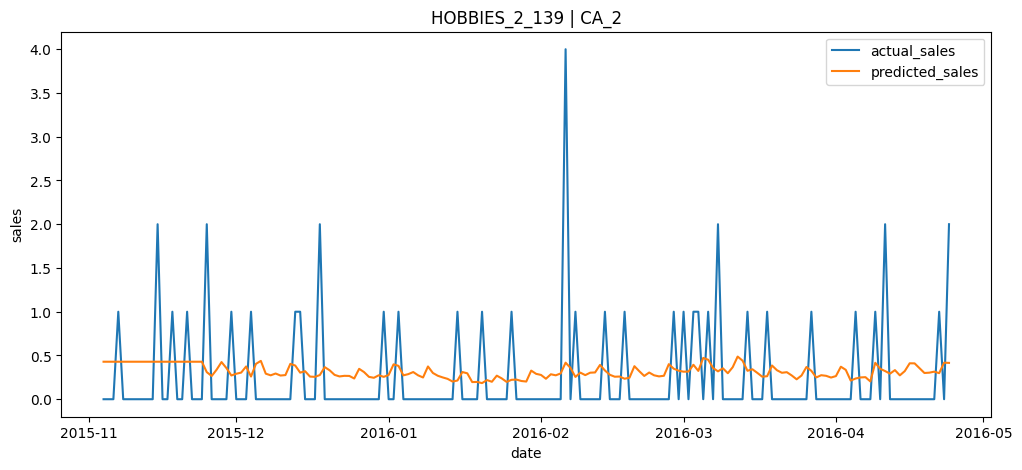

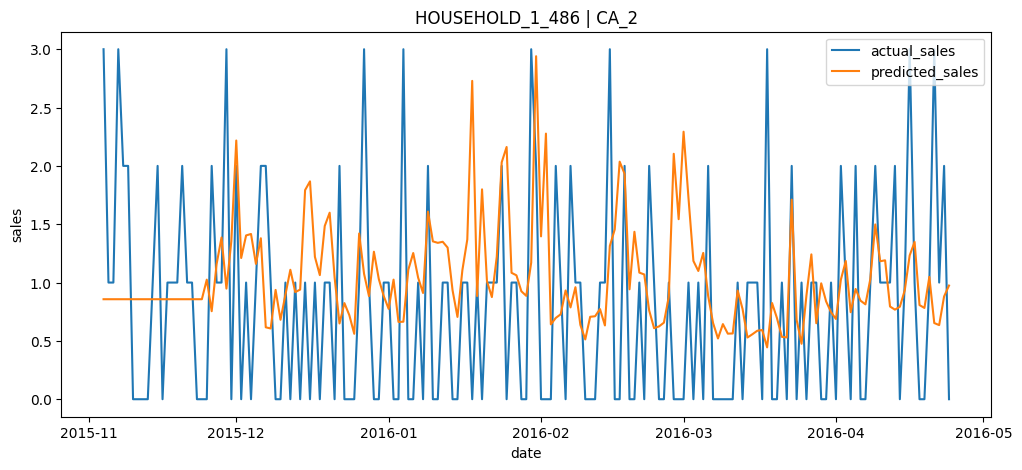

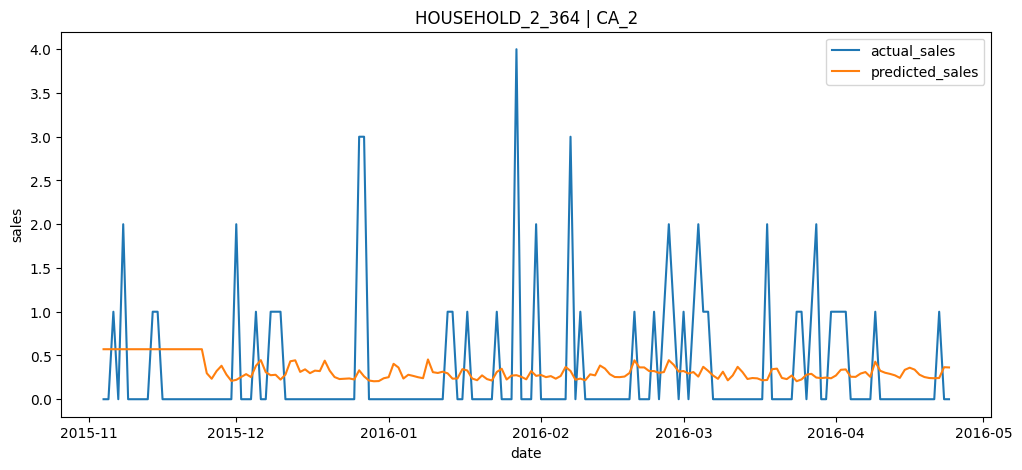

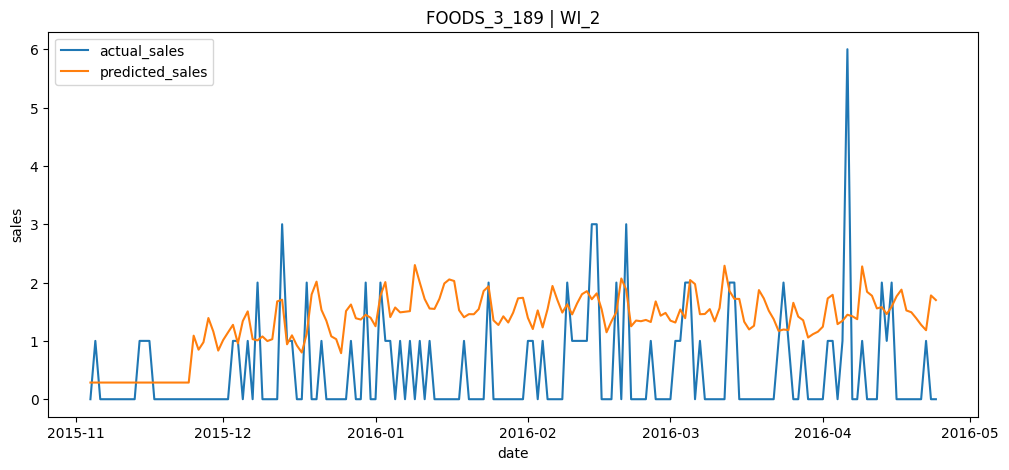

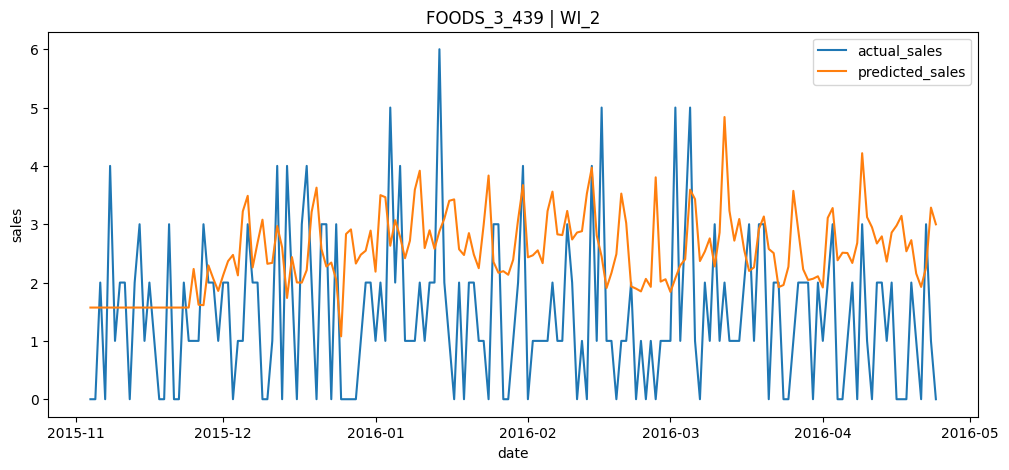

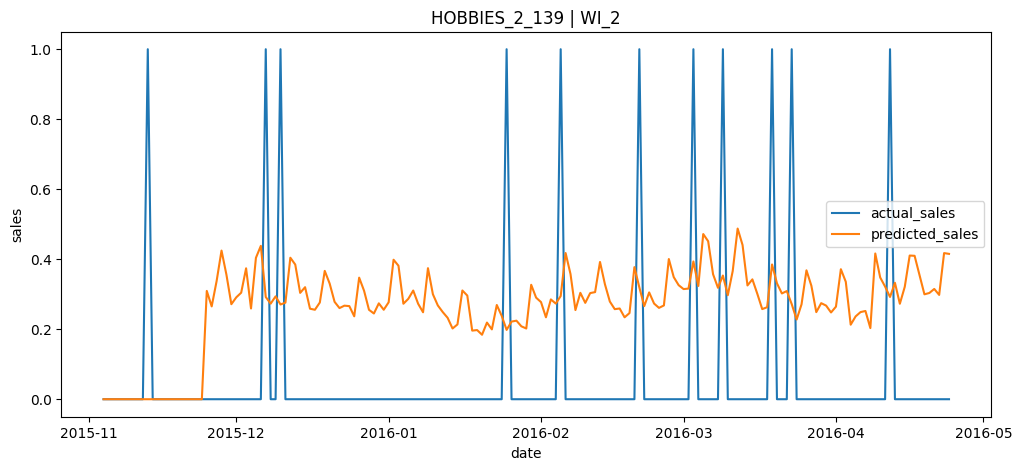

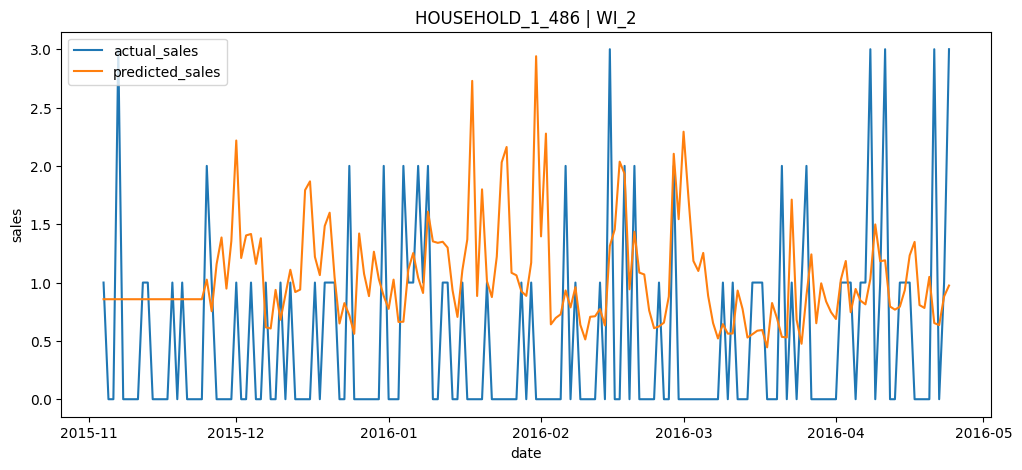

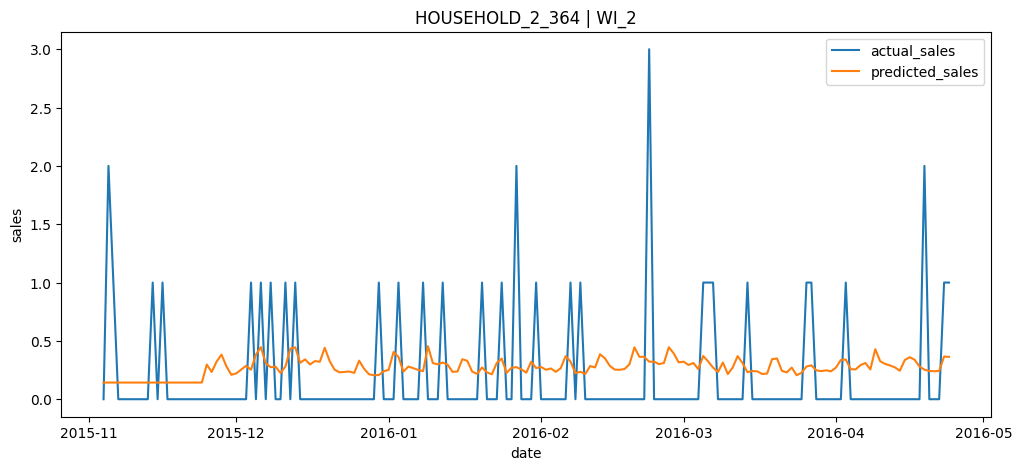

In [69]:
# Ensure date sorted
forecast_df_topk["date"] = pd.to_datetime(forecast_df_topk["date"])

cold_start_pairs = (
    forecast_df_topk[["route_b_item", "store_id"]]
    .drop_duplicates()
    .values
)

for item, store in cold_start_pairs:
    
    temp = forecast_df_topk[
        (forecast_df_topk["route_b_item"] == item) &
        (forecast_df_topk["store_id"] == store)
    ].copy()
    
    temp = temp.sort_values("date")

    plt.figure(figsize=(12, 5))

    plt.plot(
        temp["date"],
        temp["actual_sales"],
        label="actual_sales"
    )

    plt.plot(
        temp["date"],
        temp["predicted_sales"],
        label="predicted_sales"
    )

    plt.title(f"{item} | {store}")
    plt.xlabel("date")
    plt.ylabel("sales")
    plt.legend()
    plt.show()

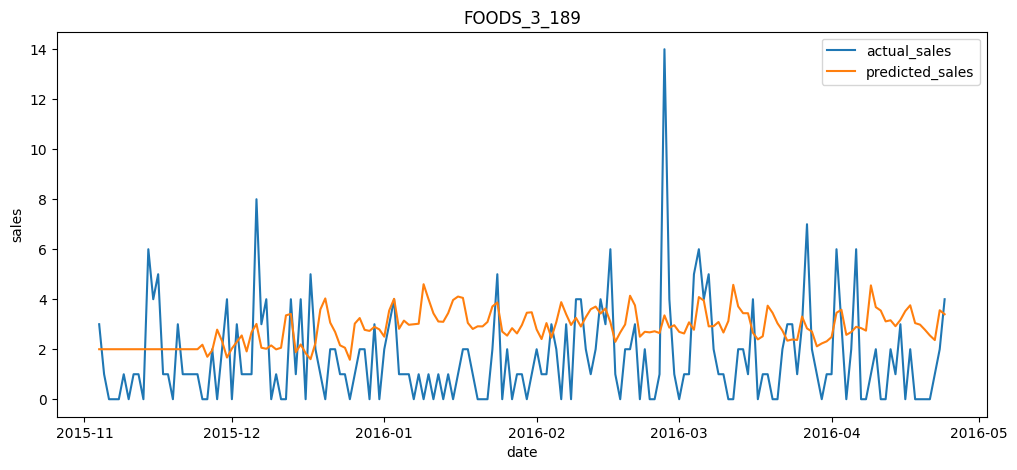

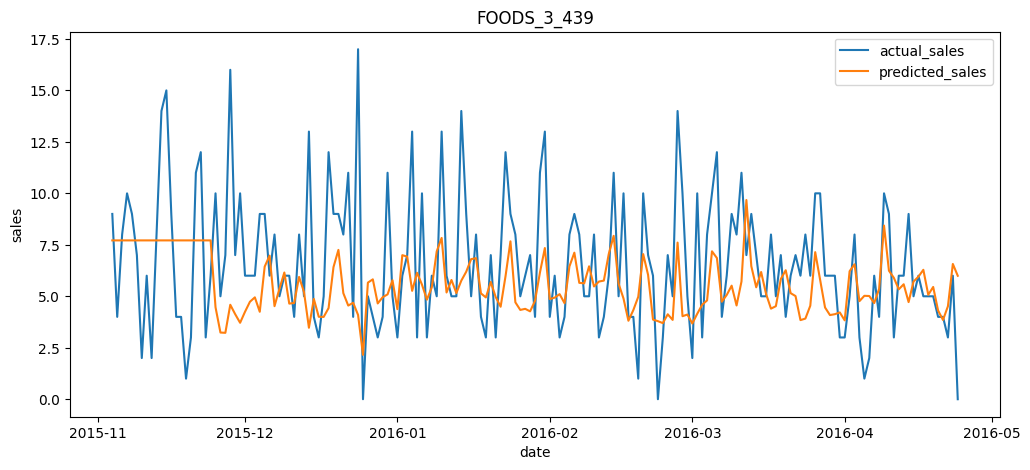

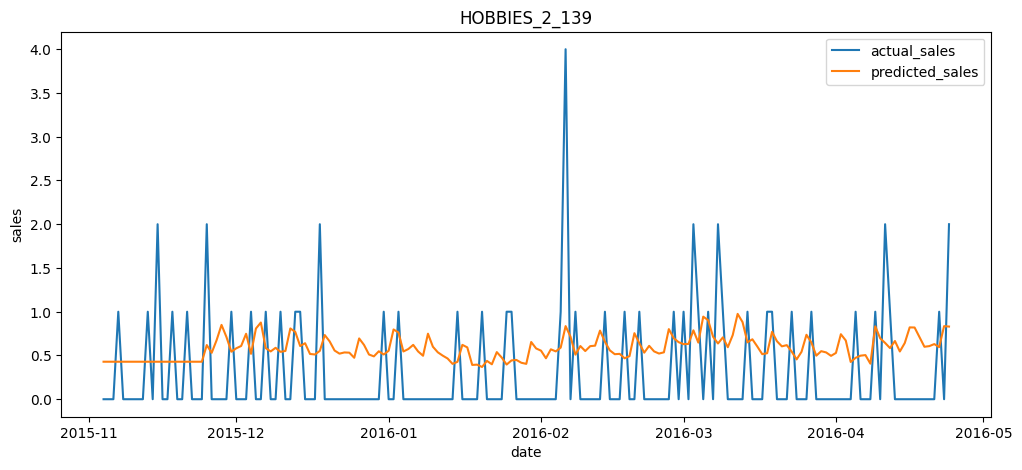

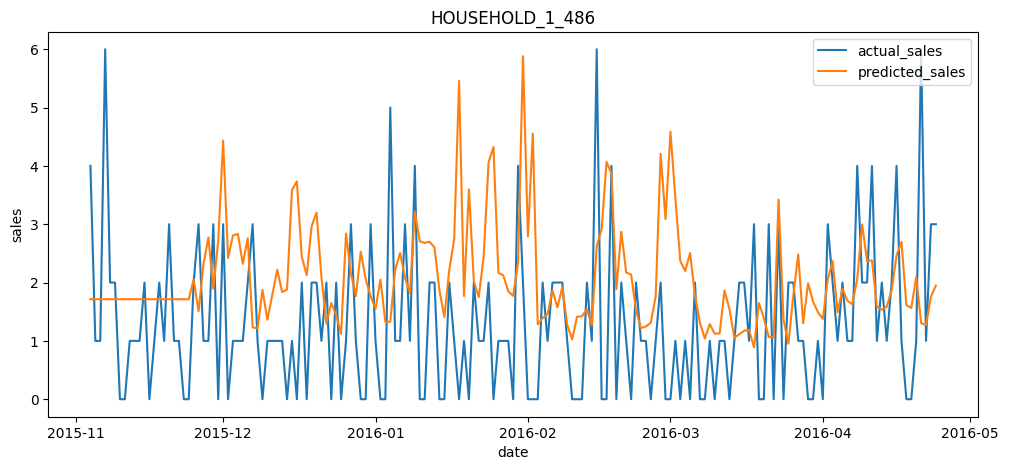

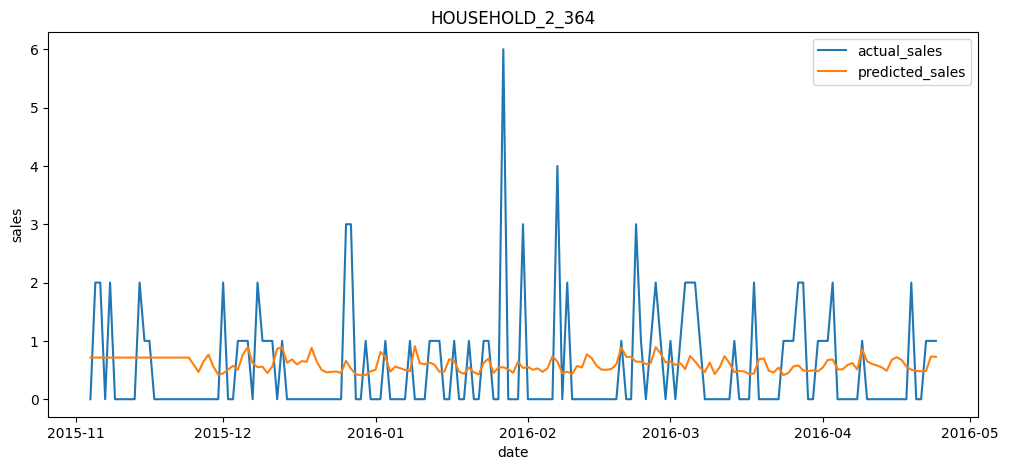

In [70]:
sku_forecast = (
    forecast_df_topk
    .groupby(["route_b_item", "date"], as_index=False)
    [["actual_sales", "predicted_sales"]]
    .sum()
)

for item in sku_forecast["route_b_item"].unique():

    temp = sku_forecast[
        sku_forecast["route_b_item"] == item
    ].sort_values("date")

    plt.figure(figsize=(12, 5))

    plt.plot(temp["date"], temp["actual_sales"], label="actual_sales")
    plt.plot(temp["date"], temp["predicted_sales"], label="predicted_sales")

    plt.title(item)
    plt.xlabel("date")
    plt.ylabel("sales")
    plt.legend()
    plt.show()

#### Save Output files

In [72]:
OUTPUT_DIR = Path("../outputs/item_level")
OUTPUT_DIR.mkdir(exist_ok=True)

route_a_metrics_df.to_csv(
    OUTPUT_DIR / "route_a_metrics.csv",
    index=False
)

route_a_predictions_df = test_df.copy()

route_a_predictions_df = route_a_predictions_df.rename(
    columns={
        "sales": "actual_sales",
        "prediction": "predicted_sales"
    }
)

route_a_predictions_df.to_csv(
    OUTPUT_DIR / "route_a_predictions.csv",
    index=False
)
topk_experiment_results_df.to_csv(
    OUTPUT_DIR / "topk_tuning_results.csv",
    index=False
)

forecast_df_topk.to_csv(
    OUTPUT_DIR / "cold_start_forecasts.csv",
    index=False
)

baseline_comparison_results.to_csv(
    OUTPUT_DIR / "method_comparison.csv",
    index=False
)

topk_similarity.to_csv(
    OUTPUT_DIR / "selected_similarity_matches.csv",
    index=False
)

Conclusion

• Built a classical Route A forecasting pipeline using XGBoost.

• Simulated cold-start products.

• Semantic retrieval outperformed category and department averages.

• Visible launch average remained the strongest simple baseline.